In [4]:
# Install seaborn directly in the notebook environment
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 🛒 Sales Advanced Analytics — Data Cleaning & Feature Engineering

**Project:** Sales Performance & Customer Behavior Analytics  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Author:** Data Analytics Portfolio Project  

---

## Workflow
1. Load raw sales data
2. Inspect data quality (nulls, duplicates, dtypes)
3. Clean and standardize the dataset
4. Engineer new analytical features
5. Perform RFM customer segmentation
6. Build cohort retention matrix
7. Generate sales forecast data
8. Export cleaned datasets for SQL & Power BI


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)

# Style
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F8F9FA",
    "axes.grid": True, "grid.alpha": 0.4, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False
})
PALETTE = ["#2E75B6","#C9A84C","#1E8449","#C84637","#8E44AD",
           "#17A589","#D35400","#2C3E50","#95A5A6","#F39C12"]

print("✅ Libraries loaded")


✅ Libraries loaded


## 1. Load Raw Data

In [ ]:
df_raw = pd.read_csv("../data/raw_sales_data.csv")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(5)


Shape: (5025, 12)
Columns: ['order_id', 'order_date', 'ship_date', 'customer_id', 'customer_name', 'region', 'category', 'product_name', 'quantity', 'unit_price', 'unit_cost', 'discount']


,order_id,order_date,ship_date,customer_id,customer_name,region,category,product_name,quantity,unit_price,unit_cost,discount
0,ORD00001,2024-02-08,2024-02-12,CUST0367,Victor Thomas,South,Office Supplies,Printer Paper,2,47.41,19.24,0.09
1,ORD00002,2022-03-26,2022-03-29,CUST0273,Bob Jackson,Central,Electronics,USB-C Hub,1,51.08,14.22,0.06
2,ORD00003,2024-01-12,2024-01-18,CUST0236,Liam Thompson,Central,Office Supplies,Printer Paper,1,51.07,18.93,0.07
3,ORD00004,2024-06-11,2024-06-18,CUST0375,Carol Jackson,South,Office Supplies,Desk Organizer,2,39.29,11.07,0.05
4,ORD00005,2024-02-16,2024-02-19,CUST0015,Iris Smith,West,Electronics,USB-C Hub,2,51.50,13.43,0.05


## 2. Data Quality Inspection

In [ ]:
print("=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
quality = pd.DataFrame({"Missing": missing, "Missing %": missing_pct,
                         "Dtype": df_raw.dtypes})
print(quality[quality["Missing"] > 0].to_string())

print(f"\nDuplicates: {df_raw.duplicated().sum():,}")
print(f"Total rows: {len(df_raw):,}")


MISSING VALUES
           Missing  Missing %    Dtype
ship_date       76       1.51      str
region          75       1.49      str
discount        75       1.49  float64

Duplicates: 25
Total rows: 5,025


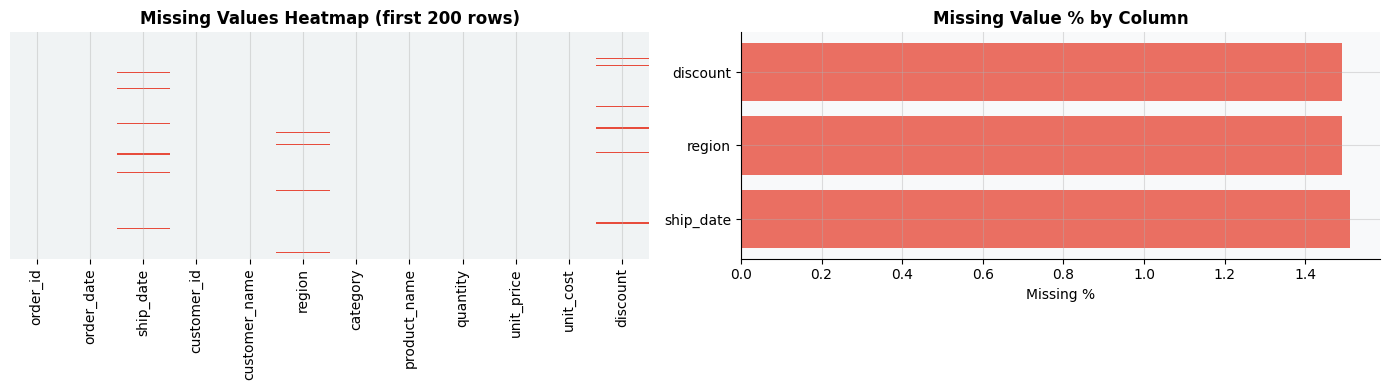

Chart saved.


In [ ]:
# Visualise missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Null heatmap (sample)
sns.heatmap(df_raw.isnull().head(200), cbar=False, yticklabels=False,
            cmap=["#F0F3F4","#E74C3C"], ax=axes[0])
axes[0].set_title("Missing Values Heatmap (first 200 rows)", fontsize=12, fontweight="bold")

# Missing % bar chart
null_df = quality[quality["Missing"] > 0].reset_index()
if not null_df.empty:
    axes[1].barh(null_df["index"], null_df["Missing %"], color="#E74C3C", alpha=0.8)
    axes[1].set_xlabel("Missing %")
    axes[1].set_title("Missing Value % by Column", fontsize=12, fontweight="bold")
else:
    axes[1].text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=14)
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig("../images/01_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")


## 3. Data Cleaning

In [ ]:
df = df_raw.copy()

# 3a. Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")

# 3b. Parse dates
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"]  = pd.to_datetime(df["ship_date"])

# 3c. Fill missing values
df["discount"].fillna(df["discount"].median(), inplace=True)
df["ship_date"].fillna(df["order_date"] + pd.Timedelta(days=3), inplace=True)
df["region"].fillna("Unknown", inplace=True)

# 3d. Standardise text
df["category"]      = df["category"].str.strip().str.title()
df["product_name"]  = df["product_name"].str.strip()
df["region"]        = df["region"].str.strip().str.title()
df["customer_name"] = df["customer_name"].str.strip().str.title()

# 3e. Validate numeric ranges
df = df[(df["unit_price"] > 0) & (df["unit_cost"] > 0) & (df["quantity"] > 0)]
df["discount"] = df["discount"].clip(0, 0.50)

print(f"Final rows: {len(df):,}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")
df.dtypes


Duplicates removed: 25
Final rows: 5,000
Remaining nulls: 225


order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
customer_id                 str
customer_name               str
region                      str
category                    str
product_name                str
quantity                  int64
unit_price              float64
unit_cost               float64
discount                float64
dtype: object

## 4. Feature Engineering

In [ ]:
# Date features
df["year"]         = df["order_date"].dt.year
df["quarter"]      = "Q" + df["order_date"].dt.quarter.astype(str)
df["month"]        = df["order_date"].dt.month
df["month_name"]   = df["order_date"].dt.strftime("%b")
df["month_year"]   = df["order_date"].dt.to_period("M").astype(str)
df["day_of_week"]  = df["order_date"].dt.day_name()
df["days_to_ship"] = (df["ship_date"] - df["order_date"]).dt.days

# Financial features
df["revenue"]       = (df["unit_price"] * df["quantity"] * (1 - df["discount"])).round(2)
df["total_cost"]    = (df["unit_cost"]  * df["quantity"]).round(2)
df["profit"]        = (df["revenue"] - df["total_cost"]).round(2)
df["profit_margin"] = (df["profit"] / df["revenue"].replace(0, np.nan) * 100).round(2)
df["order_value"]   = df["revenue"]

print("New features created:")
new_cols = ["year","quarter","month","month_name","month_year","day_of_week",
            "days_to_ship","revenue","total_cost","profit","profit_margin","order_value"]
print(df[new_cols].describe().round(2).to_string())


New features created:
          year    month  days_to_ship   revenue  total_cost   profit  profit_margin  order_value
count 5,000.00 5,000.00      4,925.00  4,925.00    5,000.00 4,925.00       4,925.00     4,925.00
mean  2,023.00     6.54          4.01    534.02      254.11   282.07          60.36       534.02
std       0.82     3.44          2.02    967.30      502.89   484.30           9.08       967.30
min   2,022.00     1.00          1.00      9.18        2.78     6.12          21.25         9.18
25%   2,022.00     4.00          2.00     65.61       21.36    43.41          54.40        65.61
50%   2,023.00     7.00          4.00    182.05       71.86   110.19          61.69       182.05
75%   2,024.00    10.00          6.00    561.87      251.65   302.09          67.26       561.87
max   2,024.00    12.00          7.00 12,775.41    5,976.50 7,333.11          79.40    12,775.41


## 5. RFM Customer Segmentation

In [ ]:
snapshot = df["order_date"].max()

rfm = df.groupby("customer_id").agg(
    recency   = ("order_date",   lambda x: (snapshot - x.max()).days),
    frequency = ("order_id",     "nunique"),
    monetary  = ("revenue",      "sum")
).reset_index().round(2)

# Score 1–5
for col, asc in [("recency", False), ("frequency", True), ("monetary", True)]:
    rfm[f"{col[0]}_score"] = pd.qcut(
        rfm[col].rank(method="first"), 5,
        labels=[5,4,3,2,1] if not asc else [1,2,3,4,5]
    ).astype(int)

rfm["rfm_total"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

def assign_segment(row):
    r, f, m = row["r_score"], row["f_score"], row["m_score"]
    if r >= 4 and f >= 4 and m >= 4: return "Champions"
    if r >= 3 and f >= 3:            return "Loyal Customers"
    if r >= 4 and f <= 2:            return "New Customers"
    if r >= 3 and f >= 2:            return "Potential Loyalists"
    if r == 2 and f >= 3:            return "At Risk"
    if r <= 2 and f >= 3:            return "Lost Customers"
    return "Others"

rfm["customer_segment"] = rfm.apply(assign_segment, axis=1)

seg_summary = rfm.groupby("customer_segment").agg(
    count    = ("customer_id","count"),
    avg_rec  = ("recency","mean"),
    avg_freq = ("frequency","mean"),
    avg_mon  = ("monetary","mean")
).round(1)
print(seg_summary.to_string())


                     count  avg_rec  avg_freq   avg_mon
customer_segment                                       
At Risk                 47   100.80     14.90  8,023.10
Champions               45    16.50     16.80 11,095.10
Lost Customers          33   181.80     13.80  6,894.60
Loyal Customers        115    36.50     14.10  6,681.90
New Customers           52    18.60      9.40  4,739.60
Others                  89   171.40      8.70  4,432.10
Potential Loyalists     19    61.40     10.70  6,147.60

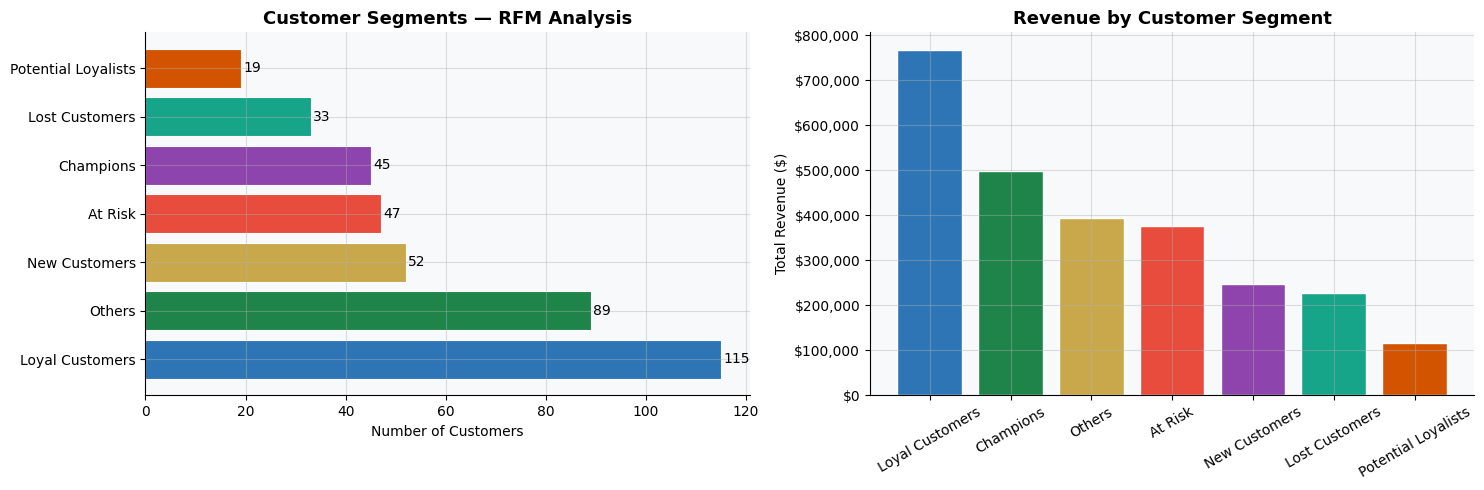

In [ ]:
# RFM Segment visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

seg_counts = rfm["customer_segment"].value_counts()
colors_seg = ["#2E75B6","#1E8449","#C9A84C","#E74C3C","#8E44AD","#17A589","#D35400"]

axes[0].barh(seg_counts.index, seg_counts.values,
             color=colors_seg[:len(seg_counts)], edgecolor="white", linewidth=0.8)
axes[0].set_title("Customer Segments — RFM Analysis", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Customers")
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 0.5, i, str(v), va="center", fontsize=10)

seg_revenue = df.merge(rfm[["customer_id","customer_segment"]], on="customer_id")                .groupby("customer_segment")["revenue"].sum().sort_values(ascending=False)
axes[1].bar(seg_revenue.index, seg_revenue.values,
            color=colors_seg[:len(seg_revenue)], edgecolor="white")
axes[1].set_title("Revenue by Customer Segment", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../images/02_rfm_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Cohort Retention Analysis

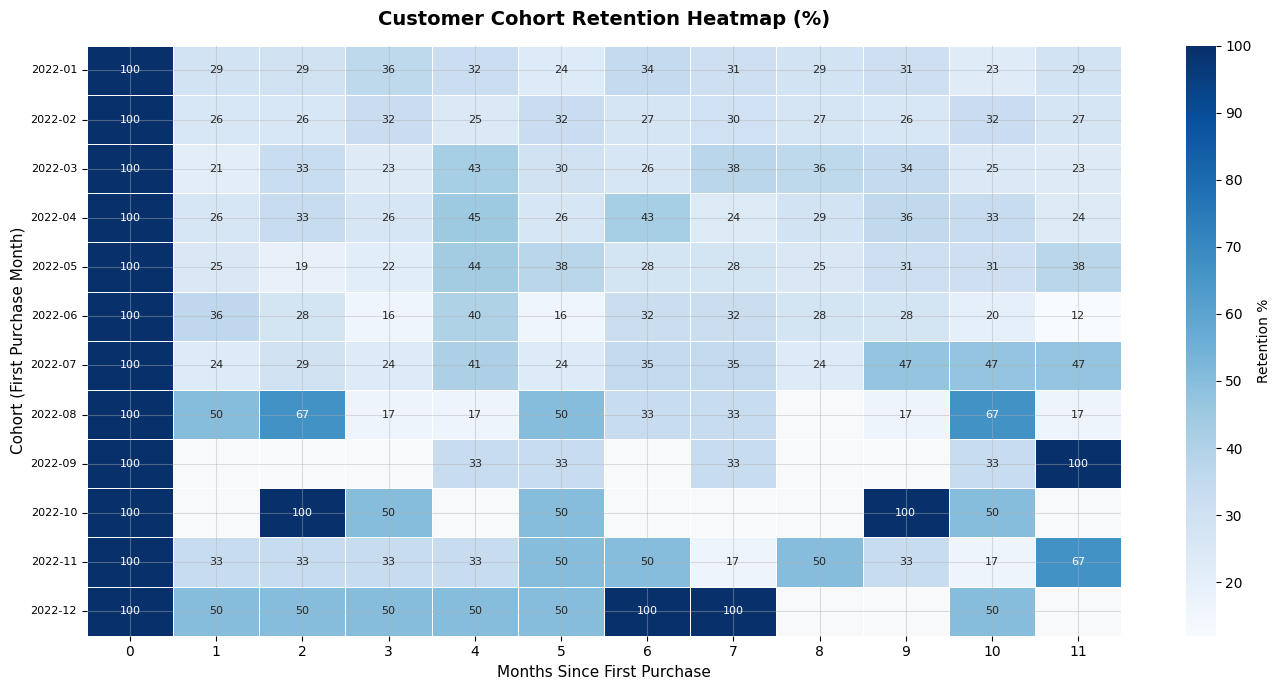

Cohort matrix shape: (18, 36)


In [ ]:
df["order_month"]   = df["order_date"].dt.to_period("M")
first_p = df.groupby("customer_id")["order_month"].min().rename("cohort_month")
df = df.join(first_p, on="customer_id")

df["cohort_index"] = ((df["order_month"].dt.year  - df["cohort_month"].dt.year) * 12
                    +  (df["order_month"].dt.month - df["cohort_month"].dt.month))

cohort_counts = (df.groupby(["cohort_month","cohort_index"])["customer_id"]
                   .nunique()
                   .reset_index()
                   .pivot(index="cohort_month", columns="cohort_index", values="customer_id"))

# Retention %
cohort_size      = cohort_counts.iloc[:, 0]
cohort_retention = (cohort_counts.divide(cohort_size, axis=0) * 100).round(1)

# Show first 12 cohort months for readability
ret_plot = cohort_retention.iloc[:12, :12]

fig, ax = plt.subplots(figsize=(14, 7))
mask = ret_plot.isnull()
sns.heatmap(ret_plot, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.4, linecolor="white",
            mask=mask, ax=ax,
            cbar_kws={"label": "Retention %"},
            annot_kws={"size": 8})
ax.set_title("Customer Cohort Retention Heatmap (%)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Months Since First Purchase", fontsize=11)
ax.set_ylabel("Cohort (First Purchase Month)", fontsize=11)
ax.set_yticklabels([str(l.get_text()) for l in ax.get_yticklabels()], rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("../images/03_cohort_retention.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Cohort matrix shape: {cohort_retention.shape}")


## 7. Sales Forecasting (Trend + Seasonality)

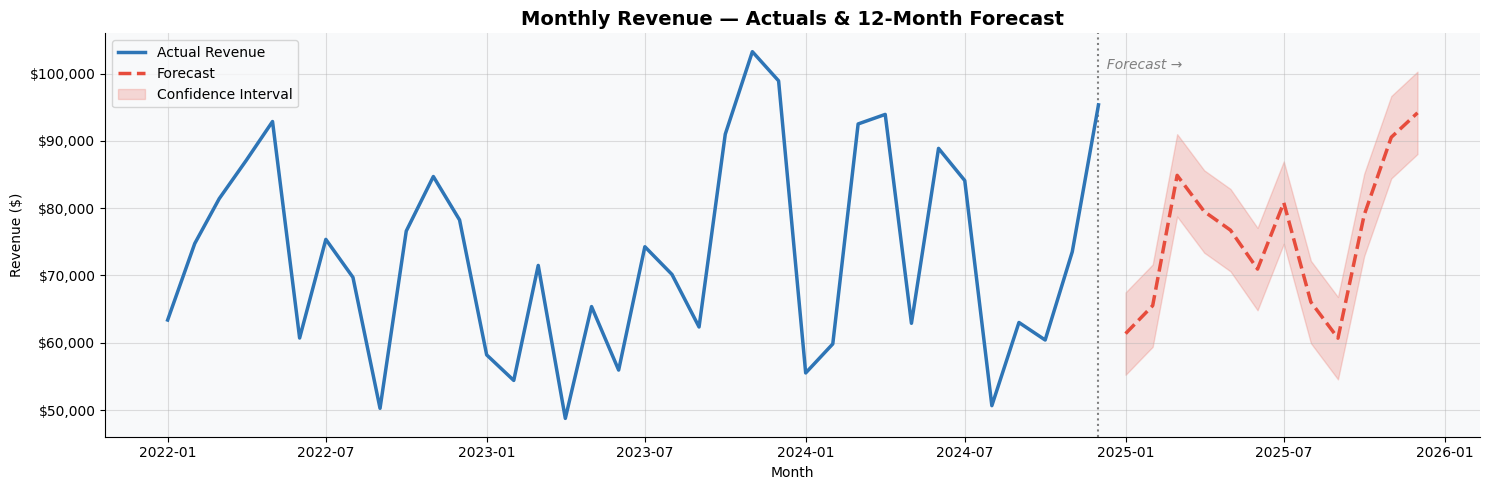

Forecast range: $60,683 – $94,177


In [ ]:
monthly_rev = (df.groupby("month_year")["revenue"].sum()
               .reset_index()
               .sort_values("month_year"))
monthly_rev["date"] = pd.to_datetime(monthly_rev["month_year"])
monthly_rev["idx"]  = range(len(monthly_rev))
monthly_rev["month_num"] = monthly_rev["date"].dt.month

# Linear trend
c = np.polyfit(monthly_rev["idx"], monthly_rev["revenue"], 1)
trend_fn = np.poly1d(c)
monthly_rev["trend"] = trend_fn(monthly_rev["idx"])

# Seasonal index
monthly_rev["detrended"] = monthly_rev["revenue"] / monthly_rev["trend"]
seas_idx = monthly_rev.groupby("month_num")["detrended"].mean()

# Forecast 12 months
last_idx  = monthly_rev["idx"].max()
last_date = monthly_rev["date"].max()
forecast  = []
for i in range(1, 13):
    fi   = last_idx + i
    fd   = last_date + pd.DateOffset(months=i)
    tv   = trend_fn(fi)
    fval = round(tv * seas_idx.get(fd.month, 1.0), 2)
    std  = monthly_rev["revenue"].std()
    forecast.append({"date": fd, "month_year": fd.strftime("%Y-%m"),
                     "forecast": fval, "lower": round(fval - std*0.4, 2),
                     "upper": round(fval + std*0.4, 2)})

fc_df = pd.DataFrame(forecast)

# Plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(monthly_rev["date"], monthly_rev["revenue"],
        color="#2E75B6", linewidth=2.5, label="Actual Revenue", zorder=3)
ax.plot(fc_df["date"], fc_df["forecast"],
        color="#E74C3C", linewidth=2.5, linestyle="--", label="Forecast", zorder=3)
ax.fill_between(fc_df["date"], fc_df["lower"], fc_df["upper"],
                alpha=0.2, color="#E74C3C", label="Confidence Interval")
ax.axvline(monthly_rev["date"].max(), color="gray", linestyle=":", linewidth=1.5)
ax.text(monthly_rev["date"].max(), ax.get_ylim()[1]*0.95, "  Forecast →",
        color="gray", fontsize=10, fontstyle="italic")
ax.set_title("Monthly Revenue — Actuals & 12-Month Forecast", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../images/04_sales_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Forecast range: ${fc_df['forecast'].min():,.0f} – ${fc_df['forecast'].max():,.0f}")


## 8. Exploratory Data Analysis — Key Business Charts

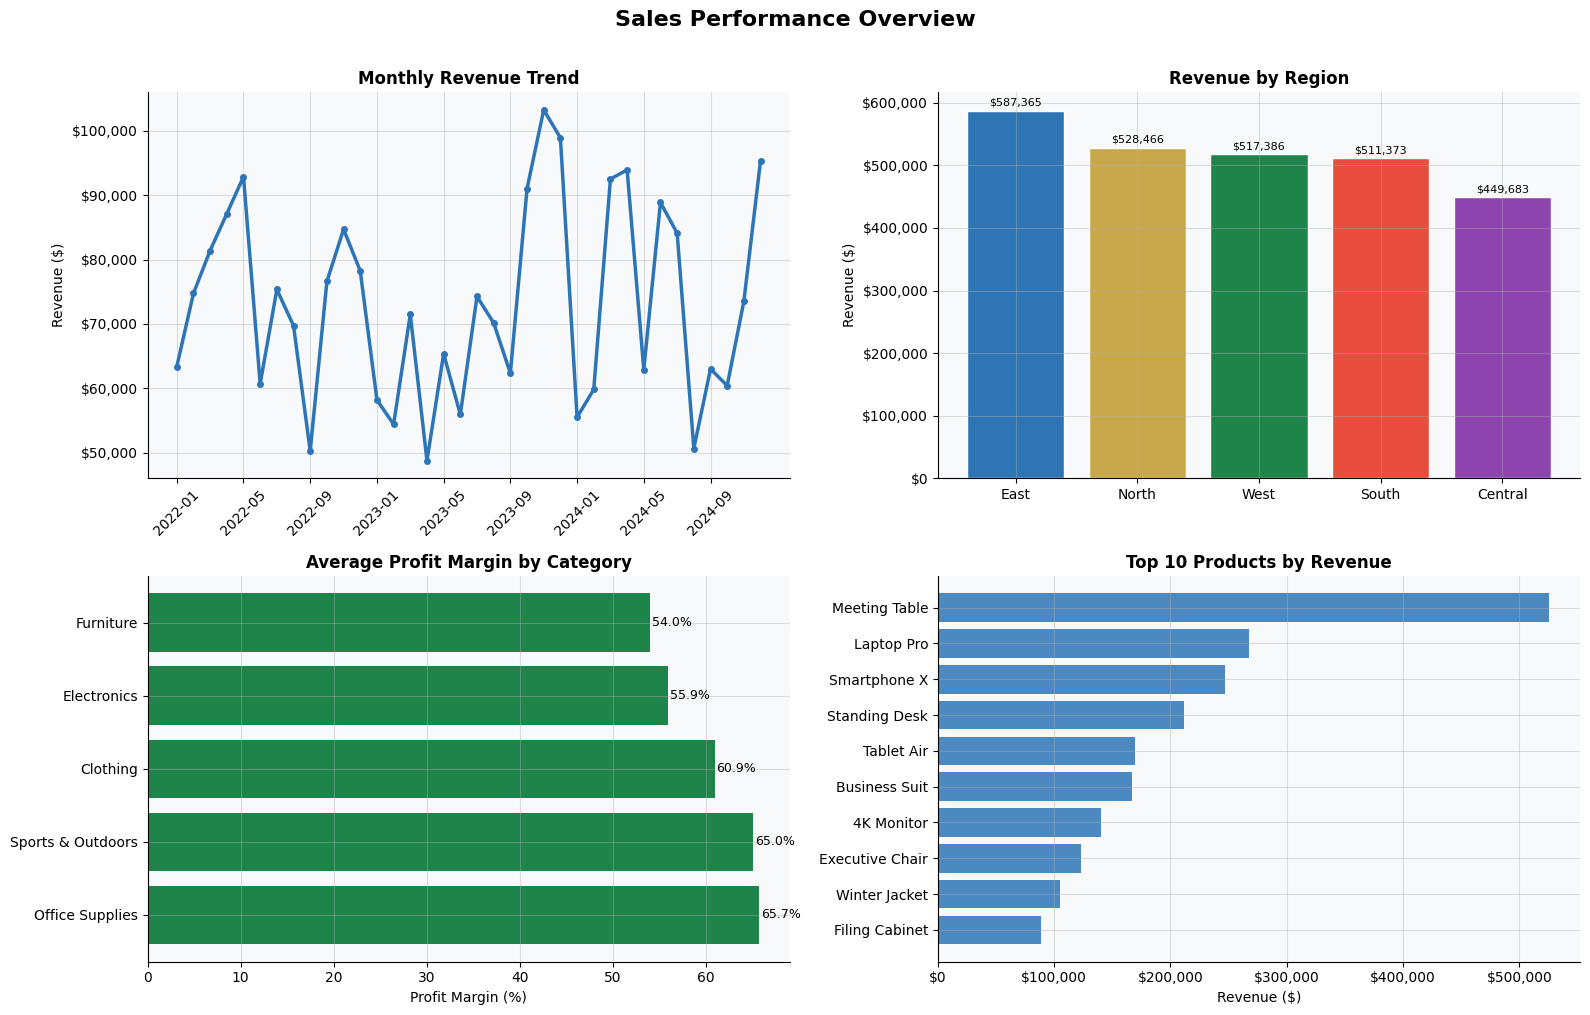

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Sales Performance Overview", fontsize=16, fontweight="bold", y=1.01)

# 8a. Monthly revenue trend
monthly_line = df.groupby("month_year")["revenue"].sum().reset_index().sort_values("month_year")
axes[0,0].plot(monthly_line["month_year"], monthly_line["revenue"],
               color="#2E75B6", linewidth=2.5, marker="o", markersize=4)
axes[0,0].set_title("Monthly Revenue Trend", fontweight="bold")
axes[0,0].set_ylabel("Revenue ($)")
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
axes[0,0].tick_params(axis="x", rotation=45)
n = len(monthly_line)
axes[0,0].set_xticks(range(0, n, max(1, n//8)))
axes[0,0].set_xticklabels(monthly_line["month_year"].iloc[::max(1,n//8)], rotation=45)

# 8b. Revenue by region
reg = df.groupby("region")["revenue"].sum().sort_values(ascending=False)
bars = axes[0,1].bar(reg.index, reg.values, color=PALETTE[:len(reg)], edgecolor="white")
axes[0,1].set_title("Revenue by Region", fontweight="bold")
axes[0,1].set_ylabel("Revenue ($)")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
for bar in bars:
    h = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2, h*1.01,
                   f"${h:,.0f}", ha="center", va="bottom", fontsize=8)

# 8c. Category profit margin
cat_margin = df.groupby("category")["profit_margin"].mean().sort_values(ascending=False)
colors_c = ["#1E8449" if v > 0 else "#E74C3C" for v in cat_margin.values]
axes[1,0].barh(cat_margin.index, cat_margin.values, color=colors_c)
axes[1,0].set_title("Average Profit Margin by Category", fontweight="bold")
axes[1,0].set_xlabel("Profit Margin (%)")
for i, v in enumerate(cat_margin.values):
    axes[1,0].text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=9)

# 8d. Top 10 products by revenue
top10 = df.groupby("product_name")["revenue"].sum().nlargest(10).sort_values()
axes[1,1].barh(top10.index, top10.values, color="#2E75B6", alpha=0.85)
axes[1,1].set_title("Top 10 Products by Revenue", fontweight="bold")
axes[1,1].set_xlabel("Revenue ($)")
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../images/05_eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Export Cleaned Datasets

In [ ]:
# Merge RFM segment back into main data
df_final = df.merge(rfm[["customer_id","recency","frequency","monetary",
                           "r_score","f_score","m_score","rfm_total","customer_segment"]],
                    on="customer_id", how="left")

# ── Cleaned main file
df_final.to_csv("../data/cleaned_sales_data.csv", index=False)

# ── RFM table
rfm.to_csv("../data/rfm_segments.csv", index=False)

# ── Cohort retention
cohort_ret_export = cohort_retention.copy()
cohort_ret_export.index = cohort_ret_export.index.astype(str)
cohort_ret_export.columns = [f"M{c}" for c in cohort_ret_export.columns]
cohort_ret_export.reset_index(inplace=True)
cohort_ret_export.rename(columns={"cohort_month":"Cohort_Month"}, inplace=True)
cohort_ret_export.to_csv("../data/cohort_retention.csv", index=False)

# ── Forecast
fc_df.to_csv("../data/sales_forecast.csv", index=False)

# ── Monthly summary
monthly_summary = df_final.groupby("month_year").agg(
    revenue       = ("revenue","sum"),
    profit        = ("profit","sum"),
    orders        = ("order_id","nunique"),
    customers     = ("customer_id","nunique"),
    avg_margin    = ("profit_margin","mean")
).round(2).reset_index()
monthly_summary.to_csv("../data/monthly_summary.csv", index=False)

print("✅ All datasets exported:")
import os
for f in os.listdir("../data"):
    size = os.path.getsize(f"../data/{f}")
    print(f"   {f:35s}  {size/1024:6.1f} KB")


✅ All datasets exported:
   cohort_retention.csv                    2.4 KB
   monthly_summary.csv                     1.4 KB
   raw_sales_data.csv                    525.7 KB
   rfm_segments.csv                       17.2 KB
   cleaned_sales_data.csv               1107.6 KB
   sales_forecast.csv                      0.6 KB


## 10. Summary Statistics

The table below shows final data quality and key business metrics after cleaning.


In [ ]:
print("=" * 55)
print("  FINAL DATASET SUMMARY")
print("=" * 55)
print(f"  Total Orders:        {df_final['order_id'].nunique():>10,}")
print(f"  Unique Customers:    {df_final['customer_id'].nunique():>10,}")
print(f"  Date Range:          {df_final['order_date'].min().date()} → {df_final['order_date'].max().date()}")
print(f"  Total Revenue:       ${df_final['revenue'].sum():>12,.2f}")
print(f"  Total Profit:        ${df_final['profit'].sum():>12,.2f}")
print(f"  Avg Profit Margin:   {df_final['profit_margin'].mean():>9.1f}%")
print(f"  Avg Order Value:     ${df_final['revenue'].mean():>10,.2f}")
print(f"  Regions:             {df_final['region'].nunique():>10}")
print(f"  Categories:          {df_final['category'].nunique():>10}")
print(f"  Products:            {df_final['product_name'].nunique():>10}")
print("=" * 55)


  FINAL DATASET SUMMARY
  Total Orders:             5,000
  Unique Customers:           400
  Date Range:          2022-01-01 → 2024-12-31
  Total Revenue:       $2,630,025.98
  Total Profit:        $1,389,215.72
  Avg Profit Margin:        60.4%
  Avg Order Value:     $    534.02
  Regions:                      5
  Categories:                   5
  Products:                    32
